In [17]:
import matplotlib.pyplot as plt

def plot_comparison_graph(baseline, batchnorm, l2):
    plt.figure(figsize=(10, 6))
    
    # בדיקה שכל המשתנים קיימים לפני הציור
    if baseline is not None:
        plt.plot(baseline, label='Baseline (Section 4)', color='blue', linestyle='--', alpha=0.7)
    
    if batchnorm is not None:
        plt.plot(batchnorm, label='With Batchnorm (Section 5)', color='red', alpha=0.8)
        
    if l2 is not None:
        plt.plot(l2, label='With L2 Regularization (Section 6)', color='green', linewidth=2)
    
    plt.title('Cost Comparison: Baseline vs Batchnorm vs L2 Regularization', fontsize=14)
    plt.xlabel('Iterations (x100)', fontsize=12)
    plt.ylabel('Cost', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()

# לפני שאת מריצה, ודאי שהגדרת את המשתנים מההרצות הקודמות שלך:
# למשל, אם בהרצה של סעיף 6 קראת לזה costs, תשמרי את זה ככה:
# costs_l2 = costs 

try:
    plot_comparison_graph(costs_baseline, costs_batchnorm, costs_l2)
except NameError as e:
    print(f"שגיאה: אחד המשתנים לא נמצא. ודאי שהגדרת את costs_baseline, costs_batchnorm ו-costs_l2")
    print(f"פרטי השגיאה: {e}")

שגיאה: אחד המשתנים לא נמצא. ודאי שהגדרת את costs_baseline, costs_batchnorm ו-costs_l2
פרטי השגיאה: name 'costs_baseline' is not defined


In [19]:
# ניסוי 1: למבדה קטנה מאוד (קרובה ל-0)
print("--- Running Experiment: lambda = 0.001 ---")
params_low, costs_low = l_layer_model(train_x, train_y, layers_dims, 
                                      learning_rate=0.009, num_iterations=100, 
                                      batch_size=512, X_val=val_x, Y_val=val_y, lambd=0.001)

# ניסוי 2: הלמבדה שבחרתן (0.1)
print("\n--- Running Experiment: lambda = 0.1 ---")
params_mid, costs_mid = l_layer_model(train_x, train_y, layers_dims, 
                                      learning_rate=0.009, num_iterations=100, 
                                      batch_size=512, X_val=val_x, Y_val=val_y, lambd=0.1)

# ניסוי 3: למבדה גבוהה (לבדיקת Underfitting)
print("\n--- Running Experiment: lambda = 1.0 ---")
params_high, costs_high = l_layer_model(train_x, train_y, layers_dims, 
                                        learning_rate=0.009, num_iterations=100, 
                                        batch_size=512, X_val=val_x, Y_val=val_y, lambd=1.0)

--- Running Experiment: lambda = 0.001 ---
Iteration 100 | Train Cost: 2.295803 | Val Cost: 2.290319
Iteration 200 | Train Cost: 2.221576 | Val Cost: 2.218245
Iteration 300 | Train Cost: 2.219150 | Val Cost: 2.213056
Iteration 400 | Train Cost: 2.255937 | Val Cost: 2.248565

⛔ Early stopping at iteration 400 (epoch 4)

--- Running Experiment: lambda = 0.1 ---
Iteration 100 | Train Cost: 2.295348 | Val Cost: 2.289900
Iteration 200 | Train Cost: 2.222967 | Val Cost: 2.219739
Iteration 300 | Train Cost: 2.220896 | Val Cost: 2.214797
Iteration 400 | Train Cost: 2.255186 | Val Cost: 2.247892

⛔ Early stopping at iteration 400 (epoch 4)

--- Running Experiment: lambda = 1.0 ---
Iteration 100 | Train Cost: 2.290802 | Val Cost: 2.285447
Iteration 200 | Train Cost: 2.214694 | Val Cost: 2.211608
Iteration 300 | Train Cost: 2.209179 | Val Cost: 2.203351
Iteration 400 | Train Cost: 2.245404 | Val Cost: 2.238467

⛔ Early stopping at iteration 400 (epoch 4)


In [20]:
# רשימת ערכי למבדה לבדיקה
lambdas_to_test = [0, 0.01, 0.1, 0.5, 10]
comparison_results = []

for l in lambdas_to_test:
    print(f"\nTesting Lambda = {l}...")
    # הרצה עם הפרמטרים המקוריים שלכן מהקוד
    params, costs = l_layer_model(train_x, train_y, layers_dims, 
                                  learning_rate=0.009, num_iterations=100, 
                                  batch_size=512, X_val=val_x, Y_val=val_y, lambd=l)
    
    # חישוב דיוקים
    train_acc = predict(train_x, train_y, params)
    val_acc = predict(val_x, val_y, params)
    
    comparison_results.append({
        'lambda': l,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'final_cost': costs[-1] if costs else None
    })

# הדפסת הטבלה לסיכום
print("\n" + "="*50)
print(f"{'Lambda':<10} | {'Train Acc':<12} | {'Val Acc':<12} | {'Cost':<10}")
print("-" * 50)
for res in comparison_results:
    print(f"{res['lambda']:<10} | {res['train_acc']:<12.4f} | {res['val_acc']:<12.4f} | {res['final_cost']:<10.4f}")


Testing Lambda = 0...
Iteration 100 | Train Cost: 1.938374 | Val Cost: 1.943917
Iteration 200 | Train Cost: 1.772671 | Val Cost: 1.778619
Iteration 300 | Train Cost: 1.676960 | Val Cost: 1.682073
Iteration 400 | Train Cost: 1.604905 | Val Cost: 1.608717
Iteration 500 | Train Cost: 1.539283 | Val Cost: 1.542075
Iteration 600 | Train Cost: 1.473078 | Val Cost: 1.474182
Iteration 700 | Train Cost: 1.406857 | Val Cost: 1.406153
Iteration 800 | Train Cost: 1.339614 | Val Cost: 1.337508
Iteration 900 | Train Cost: 1.273200 | Val Cost: 1.269717
Iteration 1000 | Train Cost: 1.210733 | Val Cost: 1.205924
Iteration 1100 | Train Cost: 1.151971 | Val Cost: 1.146111
Iteration 1200 | Train Cost: 1.097312 | Val Cost: 1.090536
Iteration 1300 | Train Cost: 1.045580 | Val Cost: 1.038559
Iteration 1400 | Train Cost: 0.995188 | Val Cost: 0.988128
Iteration 1500 | Train Cost: 0.949184 | Val Cost: 0.941859
Iteration 1600 | Train Cost: 0.906013 | Val Cost: 0.899185
Iteration 1700 | Train Cost: 0.868868 | Va

In [18]:
# ייבוא הפונקציות המדויקות שכתבתן בקבצים שלכן
from layers_utils import *
from dnn_model import l_layer_model, predict
import numpy as np

# טעינת הנתונים (שימוש בפונקציה ששלחת לי בקוד הראשי)
# ודאי שהקוד של load_and_preprocess_mnist נמצא מעל או מיובא
train_x, train_y, val_x, val_y, test_x, test_y_oh = load_and_preprocess_mnist()

# הגדרת מבנה הרשת לפי ההנחיות (עמוד 4 ו-5 בדוח)
layers_dims = [784, 20, 7, 5, 10]

Train: (784, 48000) | Val: (784, 12000) | Test: (784, 10000)


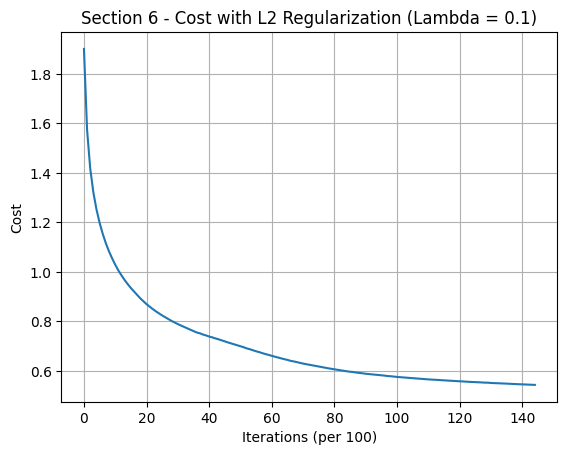

In [15]:
# הרצת הגרף עבור נתוני ה-L2 שקיבלת
plot_costs(costs_l2, title="Section 6 - Cost with L2 Regularization (Lambda = 0.1)")

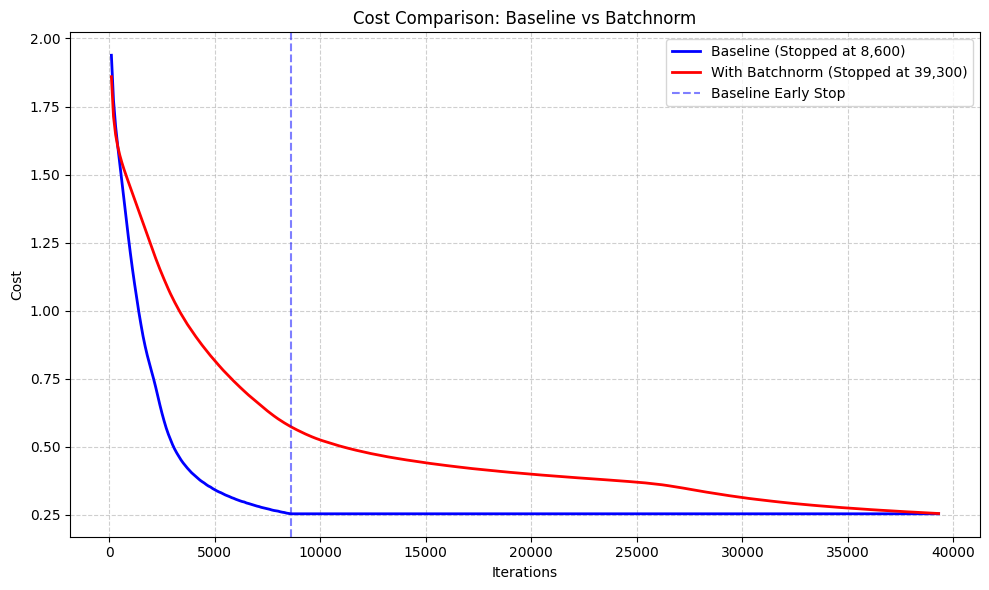

In [11]:
def plot_comparison_extended(costs_no_bn, costs_bn, title="Cost Comparison: Baseline vs Batchnorm"):
    plt.figure(figsize=(10, 6))
    
    # מוצאים מה האורך המקסימלי (של ה-BN)
    max_len = max(len(costs_no_bn), len(costs_bn))
    iters = [i * 100 for i in range(1, max_len + 1)]
    
    # "מותחים" את הקו הכחול: לוקחים את הערכים שלו ומוסיפים את הערך האחרון עד הסוף
    last_val_no_bn = costs_no_bn[-1]
    extended_no_bn = costs_no_bn + [last_val_no_bn] * (max_len - len(costs_no_bn))
    
    # "מותחים" את הקו האדום (למקרה שהוא הקצר יותר, למרות שפה הוא הארוך)
    last_val_bn = costs_bn[-1]
    extended_bn = costs_bn + [last_val_bn] * (max_len - len(costs_bn))
    
    # מציירים את הקווים המורחבים
    plt.plot(iters, extended_no_bn, label='Baseline (Stopped at 8,600)', color='blue', linewidth=2)
    plt.plot(iters, extended_bn, label='With Batchnorm (Stopped at 39,300)', color='red', linewidth=2)
    
    # הוספת קו מקווקו אנכי שמראה איפה הכחול באמת עצר (זה נראה ממש מקצועי)
    plt.axvline(x=8600, color='blue', linestyle='--', alpha=0.5, label='Baseline Early Stop')
    
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# הריצי את זה עכשיו
plot_comparison_extended(costs, costs_bn)

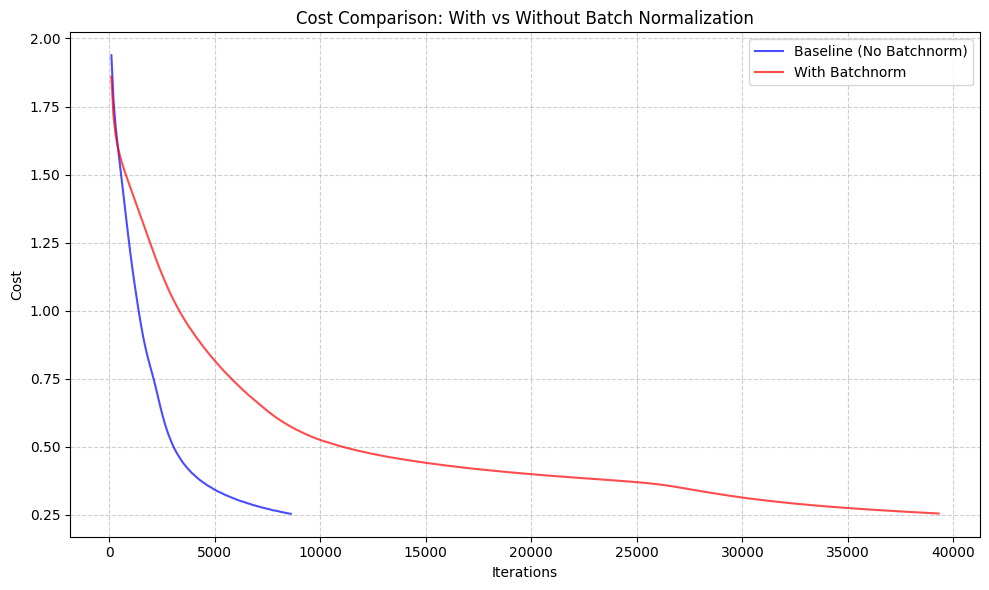

In [10]:
def plot_comparison(costs_no_bn, costs_bn, title="Comparison of Training Costs"):
    plt.figure(figsize=(10, 6))
    
    # יצירת ציר ה-X לפי קפיצות של 100 איטרציות
    iters_no_bn = [i * 100 for i in range(1, len(costs_no_bn) + 1)]
    iters_bn = [i * 100 for i in range(1, len(costs_bn) + 1)]
    
    # ציור שני הקווים
    plt.plot(iters_no_bn, costs_no_bn, label='Baseline (No Batchnorm)', color='blue', alpha=0.7)
    plt.plot(iters_bn, costs_bn, label='With Batchnorm', color='red', alpha=0.7)
    
    plt.xlabel("Iterations")
    plt.ylabel("Cost")
    plt.title(title)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# הרצה של הפונקציה עם המשתנים שלך
plot_comparison(costs, costs_bn, title="Cost Comparison: With vs Without Batch Normalization")

In [14]:
def compare_weights(params_no_l2, params_l2):
    print("Layer | Avg Weight (No L2) | Avg Weight (With L2)")
    print("-" * 45)
    for l in range(1, len(params_no_l2)//2):
        w_no_l2 = np.mean(np.abs(params_no_l2[f"W{l}"]))
        w_l2    = np.mean(np.abs(params_l2[f"W{l}"]))
        print(f"  {l}   |      {w_no_l2:.6f}      |      {w_l2:.6f}")

compare_weights(parameters_bn, parameters_l2)

Layer | Avg Weight (No L2) | Avg Weight (With L2)
---------------------------------------------
  1   |      0.040133      |      0.039034
  2   |      0.246930      |      0.226303
  3   |      0.559495      |      0.468558


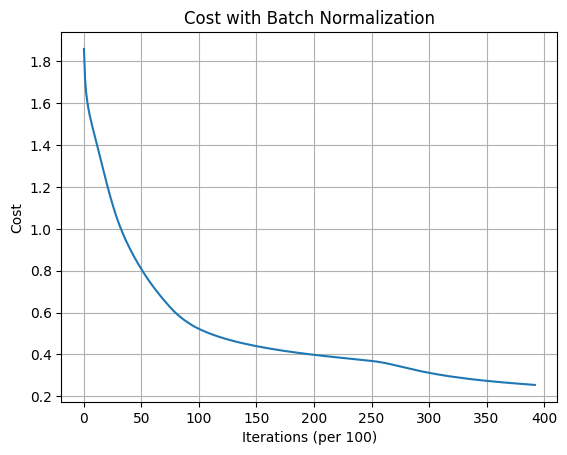

In [9]:
def plot_costs(costs, title="Model Convergence"):
    plt.plot(costs)
    plt.ylabel('Cost')
    plt.xlabel('Iterations (per 100)')
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_costs(costs_bn, title="Cost with Batch Normalization")

In [13]:
train_accuracy_l2 = predict(x_train, y_train, parameters_l2, use_batchnorm=True)
val_accuracy_l2   = predict(x_val,   y_val,   parameters_l2, use_batchnorm=True)
test_accuracy_l2  = predict(x_test,  y_test,  parameters_l2, use_batchnorm=True)

print("--- L2 Regularization Results ---")
print(f"Train Accuracy:      {train_accuracy_l2 * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy_l2 * 100:.2f}%")
print(f"Test Accuracy:       {test_accuracy_l2 * 100:.2f}%")

--- L2 Regularization Results ---
Train Accuracy:      90.48%
Validation Accuracy: 90.03%
Test Accuracy:       90.70%


In [12]:
#l2 norm
#printing the w before l2 and after

LAMBD = 0.1

parameters_l2, costs_l2 = l_layer_model(
    x_train, y_train, 
    layers_dims    = [784, 20, 7, 10], 
    learning_rate  = 0.009, 
    num_iterations = 3000, 
    batch_size     = 512, 
    use_batchnorm  = True, 
    X_val          = x_val, 
    Y_val          = y_val,
    lambd          = LAMBD  
)

Iteration 100 | Train Cost: 1.901247 | Val Cost: 1.914331
Iteration 200 | Train Cost: 1.573976 | Val Cost: 1.586157
Iteration 300 | Train Cost: 1.418622 | Val Cost: 1.428674
Iteration 400 | Train Cost: 1.322055 | Val Cost: 1.330778
Iteration 500 | Train Cost: 1.253065 | Val Cost: 1.261026
Iteration 600 | Train Cost: 1.198695 | Val Cost: 1.205962
Iteration 700 | Train Cost: 1.154016 | Val Cost: 1.160762
Iteration 800 | Train Cost: 1.115949 | Val Cost: 1.121776
Iteration 900 | Train Cost: 1.083147 | Val Cost: 1.088394
Iteration 1000 | Train Cost: 1.055056 | Val Cost: 1.060147
Iteration 1100 | Train Cost: 1.029241 | Val Cost: 1.034357
Iteration 1200 | Train Cost: 1.006056 | Val Cost: 1.011404
Iteration 1300 | Train Cost: 0.986182 | Val Cost: 0.991872
Iteration 1400 | Train Cost: 0.967298 | Val Cost: 0.972972
Iteration 1500 | Train Cost: 0.950579 | Val Cost: 0.956402
Iteration 1600 | Train Cost: 0.934971 | Val Cost: 0.940916
Iteration 1700 | Train Cost: 0.920816 | Val Cost: 0.926667
Iterat

In [8]:
train_accuracy_bn = predict(x_train, y_train, parameters_bn,True)
val_accuracy_bn   = predict(x_val,   y_val,   parameters_bn,True)
test_accuracy_bn  = predict(x_test,  y_test,  parameters_bn,True)

print(f"Train Accuracy:      {train_accuracy_bn * 100:.2f}%")
print(f"Validation Accuracy: {val_accuracy_bn * 100:.2f}%")
print(f"Test Accuracy:       {test_accuracy_bn * 100:.2f}%")

Train Accuracy:      93.67%
Validation Accuracy: 92.23%
Test Accuracy:       92.20%


In [7]:
# Batch Normalization Backpropagation (znormi):
# We calculate the gradient of the cost with respect to Z by considering 
# the influence of each Zi on the batch mean and variance. 
# This ensures the chain rule is preserved through the normalization step.

LAYER_DIMS    = [784, 20, 7, 5, 10]
LEARNING_RATE = 0.009
BATCH_SIZE    = 512
NUM_ITERATIONS = 1000 

parameters_bn, costs_bn = l_layer_model(
    x_train, y_train,
    layers_dims    = LAYER_DIMS,
    learning_rate  = LEARNING_RATE,
    num_iterations = NUM_ITERATIONS,
    batch_size     = BATCH_SIZE,
    use_batchnorm  = True,
    X_val          = x_val,
    Y_val          = y_val
)

Iteration 100 | Train Cost: 1.859572 | Val Cost: 1.864058
Iteration 200 | Train Cost: 1.713019 | Val Cost: 1.716478
Iteration 300 | Train Cost: 1.646548 | Val Cost: 1.649480
Iteration 400 | Train Cost: 1.603570 | Val Cost: 1.606172
Iteration 500 | Train Cost: 1.570697 | Val Cost: 1.573199
Iteration 600 | Train Cost: 1.543190 | Val Cost: 1.545301
Iteration 700 | Train Cost: 1.518649 | Val Cost: 1.520780
Iteration 800 | Train Cost: 1.495772 | Val Cost: 1.497967
Iteration 900 | Train Cost: 1.473901 | Val Cost: 1.476105
Iteration 1000 | Train Cost: 1.452215 | Val Cost: 1.454336
Iteration 1100 | Train Cost: 1.431119 | Val Cost: 1.433058
Iteration 1200 | Train Cost: 1.409817 | Val Cost: 1.411574
Iteration 1300 | Train Cost: 1.388026 | Val Cost: 1.389875
Iteration 1400 | Train Cost: 1.366069 | Val Cost: 1.368013
Iteration 1500 | Train Cost: 1.343813 | Val Cost: 1.345853
Iteration 1600 | Train Cost: 1.321666 | Val Cost: 1.323942
Iteration 1700 | Train Cost: 1.299879 | Val Cost: 1.302345
Iterat

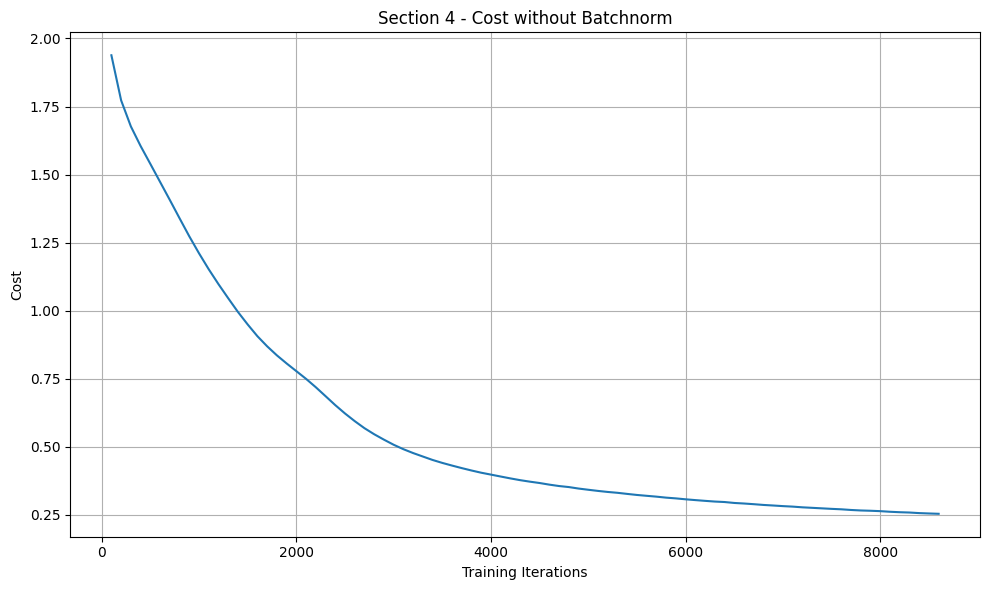

In [6]:
def plot_costs(costs, learning_rate, title="Cost over Training"):
    plt.figure(figsize=(10, 6))
    
    iterations = [i * 100 for i in range(1, len(costs) + 1)]
    
    plt.plot(iterations, costs)
    plt.xlabel("Training Iterations")
    plt.ylabel("Cost")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_costs(costs, learning_rate=0.009, title="Section 4 - Cost without Batchnorm")

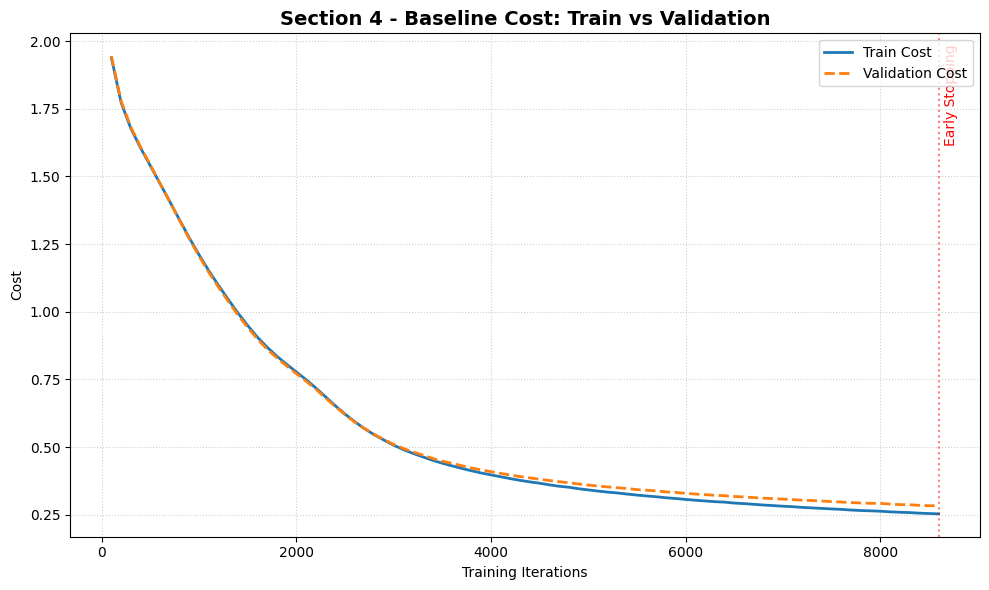

In [21]:
import matplotlib.pyplot as plt

# נתוני העלות (Cost) מתוך יומן האימון של הניסוי הראשון
iterations = [i * 100 for i in range(1, 87)]

train_costs = [
    1.938374, 1.772671, 1.676960, 1.604905, 1.539283, 1.473078, 1.406857, 1.339614, 1.273200, 1.210733,
    1.151971, 1.097312, 1.045580, 0.995188, 0.949184, 0.906013, 0.868868, 0.835662, 0.805873, 0.777559,
    0.749174, 0.718448, 0.685665, 0.652703, 0.621995, 0.593842, 0.567920, 0.545631, 0.525747, 0.506981,
    0.490701, 0.476454, 0.463714, 0.451087, 0.440228, 0.430462, 0.421134, 0.412346, 0.404162, 0.397204,
    0.390161, 0.383259, 0.376804, 0.371290, 0.366313, 0.360341, 0.355203, 0.351462, 0.345993, 0.341557,
    0.337286, 0.333487, 0.330349, 0.326289, 0.322445, 0.319311, 0.316227, 0.312561, 0.309853, 0.306450,
    0.303525, 0.300776, 0.298201, 0.296465, 0.293039, 0.291000, 0.288515, 0.285750, 0.283672, 0.281427,
    0.279593, 0.276993, 0.275132, 0.273237, 0.271326, 0.269696, 0.267254, 0.265425, 0.264364, 0.262928,
    0.260665, 0.259008, 0.257878, 0.255744, 0.254395, 0.253206
]

val_costs = [
    1.943917, 1.778619, 1.682073, 1.608717, 1.542075, 1.474182, 1.406153, 1.337508, 1.269717, 1.205924,
    1.146111, 1.090536, 1.038559, 0.988128, 0.941859, 0.899185, 0.861662, 0.829732, 0.799843, 0.771207,
    0.743547, 0.713952, 0.681217, 0.649646, 0.620105, 0.592105, 0.568672, 0.546688, 0.527622, 0.509850,
    0.494749, 0.481650, 0.470381, 0.457973, 0.447704, 0.439628, 0.430989, 0.422773, 0.415566, 0.408985,
    0.402764, 0.396437, 0.390833, 0.386051, 0.381065, 0.376402, 0.371889, 0.368188, 0.363515, 0.359601,
    0.355829, 0.352577, 0.349527, 0.346700, 0.342691, 0.340522, 0.337934, 0.334287, 0.332351, 0.328844,
    0.326490, 0.324055, 0.321812, 0.320125, 0.317410, 0.315723, 0.313246, 0.311124, 0.309463, 0.307738,
    0.305809, 0.303496, 0.302352, 0.300519, 0.298376, 0.296757, 0.294868, 0.293264, 0.292107, 0.291963,
    0.289124, 0.287411, 0.286908, 0.284654, 0.283279, 0.283291
]

def plot_cost_comparison(iterations, train_costs, val_costs, title):
    plt.figure(figsize=(10, 6))
    
    # ציור קו האימון
    plt.plot(iterations, train_costs, label="Train Cost", color='#1f77b4', linewidth=2)
    
    # ציור קו הוולידציה
    plt.plot(iterations, val_costs, label="Validation Cost", color='#ff7f0e', linestyle='--', linewidth=2)
    
    plt.xlabel("Training Iterations")
    plt.ylabel("Cost")
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # הוספת הערה על נקודת העצירה
    plt.axvline(x=8600, color='red', linestyle=':', alpha=0.5)
    plt.text(8650, 1.8, 'Early Stopping', color='red', rotation=90, verticalalignment='center')
    
    plt.tight_layout()
    plt.show()

# יצירת הגרף
plot_cost_comparison(iterations, train_costs, val_costs, "Section 4 - Baseline Cost: Train vs Validation")

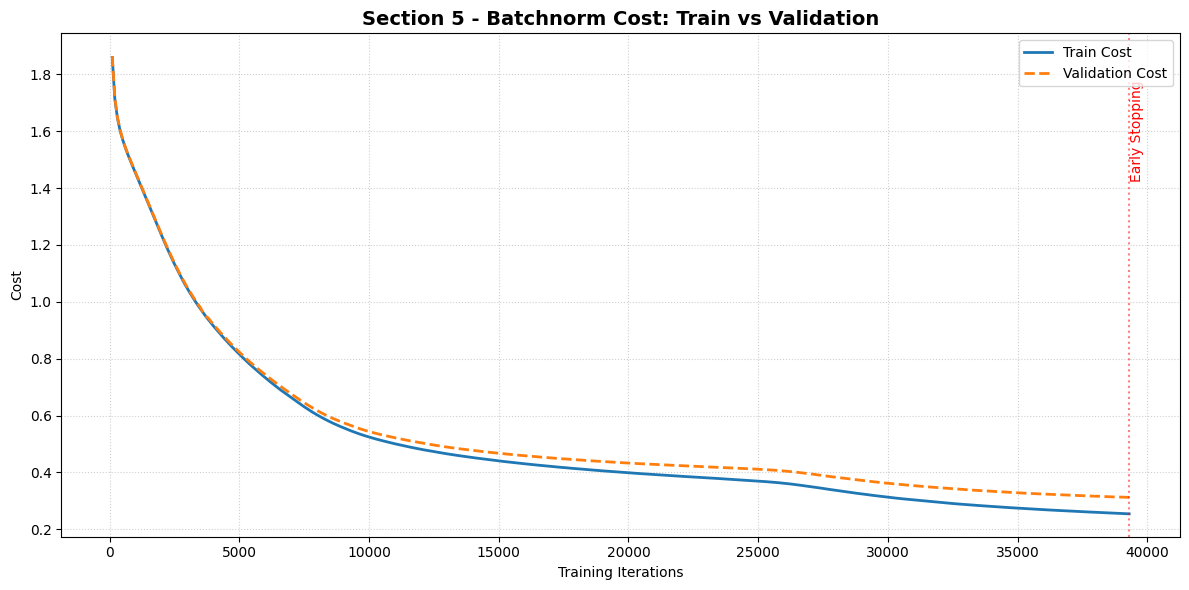

In [22]:
import matplotlib.pyplot as plt

# נתוני האיטרציות (מ-100 עד 39,300 בקפיצות של 100)
iterations = [i * 100 for i in range(1, 394)]

# רשימת נתוני ה-Train Cost המלאה
train_costs = [
    1.859572, 1.713019, 1.646548, 1.603570, 1.570697, 1.543190, 1.518649, 1.495772, 1.473901, 1.452215,
    1.431119, 1.409817, 1.388026, 1.366069, 1.343813, 1.321666, 1.299879, 1.277697, 1.255900, 1.234252,
    1.212851, 1.191886, 1.171748, 1.151823, 1.132655, 1.114435, 1.096261, 1.078773, 1.061830, 1.046063,
    1.030647, 1.015917, 1.001875, 0.988030, 0.975067, 0.962111, 0.949646, 0.938160, 0.926307, 0.915033,
    0.904401, 0.893719, 0.883063, 0.872889, 0.862994, 0.853123, 0.843411, 0.833922, 0.824824, 0.815709,
    0.806850, 0.797994, 0.789230, 0.780632, 0.772578, 0.764237, 0.756261, 0.748569, 0.740688, 0.733018,
    0.725433, 0.718151, 0.710704, 0.703663, 0.696522, 0.689459, 0.682900, 0.676106, 0.669340, 0.662873,
    0.656433, 0.649994, 0.643577, 0.637157, 0.630812, 0.624793, 0.618836, 0.613069, 0.607508, 0.602062,
    0.596944, 0.591886, 0.587064, 0.582393, 0.577895, 0.573452, 0.569267, 0.565133, 0.561216, 0.557398,
    0.553624, 0.550006, 0.546299, 0.542863, 0.539518, 0.536238, 0.533109, 0.530095, 0.527305, 0.524411,
    0.521849, 0.519418, 0.516639, 0.514151, 0.511853, 0.509553, 0.507235, 0.504984, 0.502780, 0.500597,
    0.498548, 0.496441, 0.494460, 0.492449, 0.490665, 0.488626, 0.486724, 0.484935, 0.483187, 0.481595,
    0.479607, 0.478009, 0.476178, 0.474536, 0.472993, 0.471580, 0.469952, 0.468299, 0.466977, 0.465419,
    0.464124, 0.462530, 0.461384, 0.459871, 0.458445, 0.457234, 0.455961, 0.454608, 0.453395, 0.452195,
    0.450931, 0.449759, 0.448486, 0.447320, 0.446149, 0.444908, 0.443842, 0.442908, 0.441656, 0.440456,
    0.439417, 0.438351, 0.437301, 0.436298, 0.435333, 0.434261, 0.433180, 0.432181, 0.431331, 0.430331,
    0.429315, 0.428478, 0.427461, 0.426556, 0.425657, 0.424714, 0.423728, 0.422962, 0.421986, 0.421098,
    0.420192, 0.419341, 0.418526, 0.417710, 0.416954, 0.416401, 0.415367, 0.414557, 0.413846, 0.413058,
    0.412335, 0.411762, 0.410873, 0.409893, 0.409234, 0.408574, 0.407765, 0.407024, 0.406296, 0.405547,
    0.404854, 0.404041, 0.403430, 0.402720, 0.402104, 0.401250, 0.400759, 0.399986, 0.399413, 0.398801,
    0.398033, 0.397328, 0.396657, 0.396053, 0.395488, 0.394878, 0.394297, 0.393668, 0.393087, 0.392439,
    0.391854, 0.391237, 0.390604, 0.390154, 0.389445, 0.388848, 0.388312, 0.387723, 0.387156, 0.386586,
    0.386028, 0.385426, 0.384926, 0.384245, 0.383716, 0.383204, 0.382715, 0.382161, 0.381617, 0.380999,
    0.380479, 0.379859, 0.379359, 0.378890, 0.378303, 0.377758, 0.377248, 0.376643, 0.376072, 0.375469,
    0.374798, 0.374322, 0.373777, 0.373055, 0.372624, 0.371929, 0.371328, 0.370712, 0.370107, 0.369531,
    0.368778, 0.368189, 0.367472, 0.366744, 0.365909, 0.365333, 0.364449, 0.363628, 0.362703, 0.361748,
    0.360755, 0.359795, 0.358752, 0.357669, 0.356399, 0.355178, 0.353933, 0.352646, 0.351407, 0.350047,
    0.348835, 0.347641, 0.346177, 0.345008, 0.343517, 0.342186, 0.340794, 0.339470, 0.338266, 0.336845,
    0.335456, 0.334170, 0.332825, 0.331576, 0.330319, 0.329198, 0.327829, 0.326599, 0.325491, 0.324184,
    0.322906, 0.321963, 0.320598, 0.319495, 0.318391, 0.317321, 0.316129, 0.314983, 0.313953, 0.312806,
    0.311889, 0.310735, 0.309736, 0.308895, 0.307848, 0.306845, 0.305969, 0.304998, 0.304074, 0.303086,
    0.302248, 0.301379, 0.300486, 0.299582, 0.298635, 0.297764, 0.297086, 0.296138, 0.295280, 0.294523,
    0.293704, 0.292905, 0.292263, 0.291318, 0.290559, 0.289926, 0.289074, 0.288328, 0.287596, 0.286950,
    0.286233, 0.285611, 0.284853, 0.284309, 0.283423, 0.282854, 0.282201, 0.281453, 0.280962, 0.280248,
    0.279612, 0.278962, 0.278394, 0.277886, 0.277256, 0.276536, 0.276023, 0.275460, 0.274907, 0.274373,
    0.273818, 0.273193, 0.272599, 0.271973, 0.271545, 0.271043, 0.270530, 0.270020, 0.269433, 0.268958,
    0.268463, 0.268086, 0.267497, 0.266899, 0.266496, 0.266122, 0.265635, 0.265201, 0.264781, 0.264263,
    0.263757, 0.263300, 0.262694, 0.262298, 0.261870, 0.261363, 0.260988, 0.260505, 0.260234, 0.259634,
    0.259326, 0.258928, 0.258438, 0.257901, 0.257511, 0.257072, 0.256772, 0.256423, 0.255943, 0.255415,
    0.255004, 0.254638, 0.254268
]

# רשימת נתוני ה-Validation Cost המלאה
val_costs = [
    1.864058, 1.716478, 1.649480, 1.606172, 1.573199, 1.545301, 1.520780, 1.497967, 1.476105, 1.454336,
    1.433058, 1.411574, 1.389875, 1.368013, 1.345853, 1.323942, 1.302345, 1.280305, 1.258663, 1.237367,
    1.216235, 1.195526, 1.175405, 1.155369, 1.136080, 1.117896, 1.099953, 1.082627, 1.065798, 1.050230,
    1.034765, 1.019931, 1.005873, 0.992228, 0.979580, 0.962111, 0.949646, 0.943446, 0.931583, 0.920418,
    0.909915, 0.899307, 0.888884, 0.878858, 0.869269, 0.859569, 0.850059, 0.840936, 0.832020, 0.823038,
    0.814494, 0.805914, 0.797359, 0.789100, 0.781296, 0.773194, 0.765514, 0.758170, 0.750748, 0.743455,
    0.736319, 0.729291, 0.722262, 0.715479, 0.708774, 0.701914, 0.695473, 0.688706, 0.682175, 0.675879,
    0.669713, 0.663364, 0.657261, 0.651076, 0.645071, 0.639342, 0.633677, 0.628216, 0.622753, 0.617507,
    0.612550, 0.607713, 0.603093, 0.598654, 0.594376, 0.590132, 0.586284, 0.582379, 0.578704, 0.575102,
    0.571694, 0.568172, 0.564893, 0.561563, 0.558431, 0.555058, 0.551965, 0.549145, 0.546364, 0.543713,
    0.541260, 0.538943, 0.536447, 0.534188, 0.532059, 0.529873, 0.527828, 0.525722, 0.523696, 0.521759,
    0.519848, 0.517828, 0.516017, 0.514001, 0.512419, 0.510623, 0.509021, 0.507237, 0.505629, 0.504155,
    0.502379, 0.500903, 0.499299, 0.497737, 0.496334, 0.495005, 0.493565, 0.491978, 0.490634, 0.489257,
    0.488263, 0.486576, 0.485666, 0.484260, 0.482983, 0.482014, 0.480970, 0.479765, 0.478657, 0.477599,
    0.476432, 0.475384, 0.474234, 0.473184, 0.472253, 0.471103, 0.470294, 0.469300, 0.468367, 0.467385,
    0.466540, 0.465493, 0.464597, 0.463810, 0.463032, 0.462168, 0.461113, 0.460287, 0.459657, 0.458747,
    0.457944, 0.457137, 0.456446, 0.455689, 0.454841, 0.454005, 0.453276, 0.452562, 0.451736, 0.450984,
    0.450348, 0.449580, 0.448811, 0.448165, 0.447585, 0.447254, 0.446263, 0.445595, 0.445146, 0.444560,
    0.443745, 0.443394, 0.442515, 0.441766, 0.441186, 0.440689, 0.439984, 0.439416, 0.438826, 0.438317,
    0.437705, 0.437049, 0.436568, 0.435814, 0.435438, 0.434808, 0.434314, 0.433892, 0.433296, 0.432815,
    0.432258, 0.431751, 0.431274, 0.430876, 0.430391, 0.429890, 0.429564, 0.429097, 0.428714, 0.428244,
    0.427716, 0.427273, 0.426884, 0.426368, 0.425872, 0.425499, 0.425106, 0.424698, 0.424330, 0.423891,
    0.423765, 0.423224, 0.422892, 0.422301, 0.422188, 0.421705, 0.421227, 0.420874, 0.420333, 0.419741,
    0.419464, 0.419011, 0.418661, 0.418321, 0.417921, 0.417482, 0.417121, 0.416696, 0.416360, 0.415859,
    0.415313, 0.414903, 0.414573, 0.414090, 0.413517, 0.413177, 0.412587, 0.412235, 0.411822, 0.411323,
    0.410799, 0.410198, 0.409755, 0.409254, 0.408573, 0.408106, 0.407435, 0.406784, 0.405973, 0.405199,
    0.404390, 0.403314, 0.402441, 0.401585, 0.400473, 0.399442, 0.398357, 0.397198, 0.396105, 0.394920,
    0.393673, 0.392704, 0.391180, 0.390156, 0.388733, 0.387695, 0.386323, 0.385168, 0.384051, 0.382742,
    0.381501, 0.380487, 0.379384, 0.378188, 0.376994, 0.376100, 0.374838, 0.373714, 0.372820, 0.371604,
    0.370572, 0.369824, 0.368537, 0.367500, 0.366519, 0.365681, 0.364679, 0.363549, 0.362689, 0.361800,
    0.360873, 0.359717, 0.359163, 0.358336, 0.357136, 0.356380, 0.355642, 0.354943, 0.354248, 0.353190,
    0.352630, 0.351875, 0.351031, 0.350340, 0.349577, 0.348810, 0.348192, 0.347452, 0.346551, 0.345986,
    0.345213, 0.344794, 0.344090, 0.343375, 0.342709, 0.341994, 0.341391, 0.340620, 0.339915, 0.339194,
    0.338746, 0.338063, 0.337442, 0.336888, 0.336114, 0.335770, 0.335117, 0.334508, 0.333997, 0.333259,
    0.332639, 0.332285, 0.331751, 0.331101, 0.330653, 0.330156, 0.329657, 0.329139, 0.328889, 0.328191,
    0.327837, 0.327328, 0.327030, 0.326333, 0.325982, 0.325564, 0.325090, 0.324688, 0.324297, 0.323957,
    0.323475, 0.323190, 0.322405, 0.322188, 0.321544, 0.321473, 0.320989, 0.320702, 0.320343, 0.319985,
    0.319350, 0.319209, 0.318851, 0.318441, 0.317796, 0.317455, 0.317083, 0.316840, 0.316519, 0.316205,
    0.316162, 0.315539, 0.315252, 0.315063, 0.314587, 0.314113, 0.314036, 0.313640, 0.313484, 0.313181,
    0.312762, 0.312488, 0.312486
]

def plot_cost_comparison_bn(iterations, train_costs, val_costs, title):
    plt.figure(figsize=(12, 6))
    
    # ציור קו האימון
    plt.plot(iterations, train_costs, label="Train Cost", color='#1f77b4', linewidth=2)
    
    # ציור קו הוולידציה
    plt.plot(iterations, val_costs, label="Validation Cost", color='#ff7f0e', linestyle='--', linewidth=2)
    
    plt.xlabel("Training Iterations")
    plt.ylabel("Cost")
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # סימון נקודת העצירה המוקדמת ב-39,300
    plt.axvline(x=39300, color='red', linestyle=':', alpha=0.5)
    plt.text(39350, 1.6, 'Early Stopping', color='red', rotation=90, verticalalignment='center')
    
    plt.tight_layout()
    plt.show()

# יצירת הגרף
plot_cost_comparison_bn(iterations, train_costs, val_costs, "Section 5 - Batchnorm Cost: Train vs Validation")

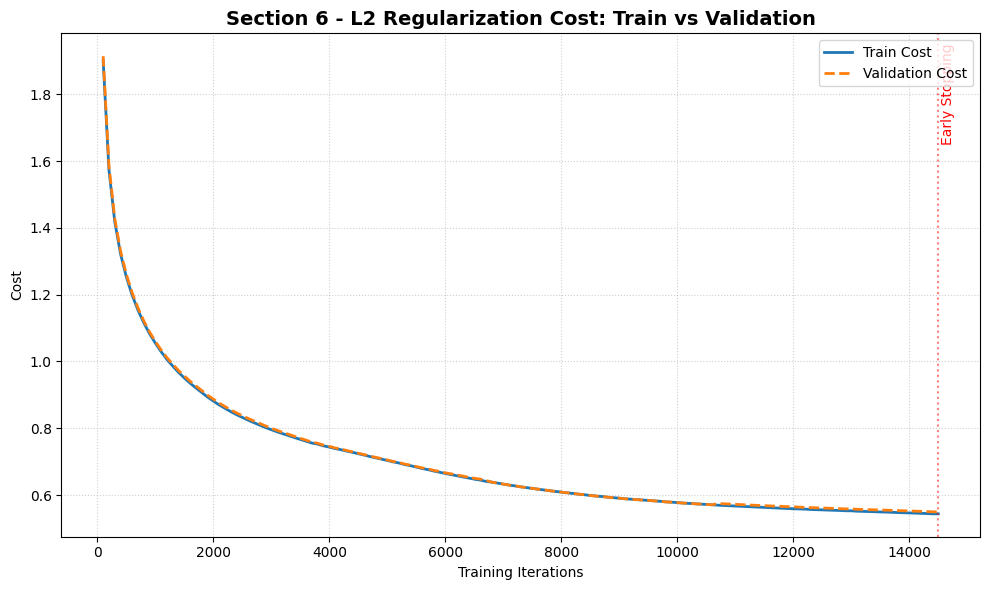

In [23]:
import matplotlib.pyplot as plt

# נתוני האיטרציות עבור הניסוי השלישי
iterations = [i * 100 for i in range(1, 146)]

# רשימת נתוני ה-Train Cost
train_costs = [
    1.901247, 1.573976, 1.418622, 1.322055, 1.253065, 1.198695, 1.154016, 1.115949, 1.083147, 1.055056,
    1.029241, 1.006056, 0.986182, 0.967298, 0.950579, 0.934971, 0.920816, 0.907274, 0.893454, 0.881682,
    0.869869, 0.859762, 0.849883, 0.840758, 0.832477, 0.824238, 0.816711, 0.809338, 0.802128, 0.795757,
    0.789321, 0.783528, 0.777604, 0.772028, 0.766625, 0.761292, 0.755664, 0.752360, 0.747243, 0.743612,
    0.739068, 0.735788, 0.731516, 0.727947, 0.723663, 0.719744, 0.715295, 0.711364, 0.707580, 0.703603,
    0.699226, 0.695996, 0.691223, 0.687860, 0.683660, 0.679489, 0.676154, 0.671863, 0.668210, 0.664236,
    0.661129, 0.657686, 0.654228, 0.650462, 0.647535, 0.644768, 0.640882, 0.638678, 0.635695, 0.632418,
    0.629819, 0.627408, 0.624572, 0.622179, 0.620111, 0.617455, 0.614938, 0.612871, 0.610923, 0.608660,
    0.606716, 0.604623, 0.602622, 0.600876, 0.598667, 0.596886, 0.595679, 0.593527, 0.592215, 0.590582,
    0.588766, 0.587525, 0.586124, 0.584894, 0.583553, 0.582404, 0.581329, 0.579508, 0.578694, 0.577225,
    0.575934, 0.574931, 0.573723, 0.572933, 0.571666, 0.570749, 0.569578, 0.568891, 0.567873, 0.566998,
    0.565980, 0.565366, 0.564578, 0.563589, 0.562925, 0.562094, 0.561272, 0.560464, 0.559757, 0.558847,
    0.558292, 0.557765, 0.556742, 0.556070, 0.555601, 0.554989, 0.554314, 0.553781, 0.552858, 0.552728,
    0.551542, 0.551073, 0.550721, 0.549997, 0.549225, 0.548915, 0.548070, 0.547558, 0.546982, 0.546168,
    0.545726, 0.545239, 0.544606, 0.543665, 0.543761
]

# רשימת נתוני ה-Validation Cost
val_costs = [
    1.914331, 1.586157, 1.428674, 1.330778, 1.261026, 1.205962, 1.160762, 1.121776, 1.088394, 1.060147,
    1.034357, 1.011404, 0.991872, 0.972972, 0.956402, 0.940916, 0.926667, 0.913142, 0.899038, 0.887421,
    0.875292, 0.865219, 0.855214, 0.846072, 0.837795, 0.829444, 0.821884, 0.814335, 0.806953, 0.800401,
    0.793637, 0.787663, 0.781459, 0.775508, 0.769888, 0.764348, 0.758346, 0.754929, 0.749481, 0.745845,
    0.740974, 0.737769, 0.733316, 0.729511, 0.725135, 0.721212, 0.716727, 0.712829, 0.709075, 0.705123,
    0.700623, 0.697536, 0.692681, 0.689449, 0.685344, 0.681340, 0.678092, 0.673956, 0.670409, 0.666461,
    0.663496, 0.660183, 0.656839, 0.653143, 0.650274, 0.647824, 0.643908, 0.638678, 0.635695, 0.632418,
    0.629819, 0.627408, 0.624572, 0.622179, 0.620111, 0.617455, 0.614938, 0.612871, 0.610923, 0.608660,
    0.606716, 0.604623, 0.602622, 0.600876, 0.598667, 0.596886, 0.595679, 0.593527, 0.592215, 0.590582,
    0.588766, 0.587525, 0.586124, 0.584894, 0.583553, 0.582404, 0.581329, 0.579508, 0.578694, 0.577225,
    0.575934, 0.574931, 0.573723, 0.572933, 0.571666, 0.570749, 0.574645, 0.573964, 0.573007, 0.572154,
    0.571156, 0.570682, 0.569875, 0.568856, 0.568308, 0.567443, 0.566707, 0.565794, 0.565135, 0.564334,
    0.563830, 0.563300, 0.562295, 0.561633, 0.561201, 0.560602, 0.559935, 0.559398, 0.558490, 0.558476,
    0.557249, 0.556761, 0.556461, 0.555769, 0.554980, 0.554684, 0.553905, 0.553440, 0.552887, 0.552037,
    0.551663, 0.551178, 0.550612, 0.549663, 0.549813
]

def plot_cost_comparison_l2(iterations, train_costs, val_costs, title):
    plt.figure(figsize=(10, 6))
    
    # ציור קו האימון
    plt.plot(iterations, train_costs, label="Train Cost", color='#1f77b4', linewidth=2)
    
    # ציור קו הוולידציה
    plt.plot(iterations, val_costs, label="Validation Cost", color='#ff7f0e', linestyle='--', linewidth=2)
    
    plt.xlabel("Training Iterations")
    plt.ylabel("Cost")
    plt.title(title, fontsize=14, fontweight='bold')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle=':', alpha=0.6)
    
    # סימון נקודת העצירה המוקדמת ב-14,500
    plt.axvline(x=14500, color='red', linestyle=':', alpha=0.5)
    plt.text(14550, 1.8, 'Early Stopping', color='red', rotation=90, verticalalignment='center')
    
    plt.tight_layout()
    plt.show()

# יצירת הגרף
plot_cost_comparison_l2(iterations, train_costs, val_costs, "Section 6 - L2 Regularization Cost: Train vs Validation")

In [5]:
train_accuracy = predict(x_train, y_train, parameters)
val_accuracy   = predict(x_val,   y_val,   parameters)
test_accuracy  = predict(x_test,  y_test,  parameters)

print(f" train accuracy:     {train_accuracy * 100:.2f}%")
print(f" validation accuracy:  {val_accuracy * 100:.2f}%")
print(f" test accuracy:       {test_accuracy * 100:.2f}%")

 train accuracy:     93.31%
 validation accuracy:  92.56%
 test accuracy:       92.58%


In [ ]:
LAYER_DIMS    = [784, 20, 7, 5, 10]
LEARNING_RATE = 0.009
BATCH_SIZE    = 512
NUM_ITERATIONS = 1000 

parameters, costs = l_layer_model(
    x_train, y_train,
    layers_dims    = LAYER_DIMS,
    learning_rate  = LEARNING_RATE,
    num_iterations = NUM_ITERATIONS,
    batch_size     = BATCH_SIZE,
    use_batchnorm  = False,
    X_val          = x_val,
    Y_val          = y_val
)

Iteration 100 | Train Cost: 1.938374 | Val Cost: 1.943917
Iteration 200 | Train Cost: 1.772671 | Val Cost: 1.778619
Iteration 300 | Train Cost: 1.676960 | Val Cost: 1.682073
Iteration 400 | Train Cost: 1.604905 | Val Cost: 1.608717
Iteration 500 | Train Cost: 1.539283 | Val Cost: 1.542075
Iteration 600 | Train Cost: 1.473078 | Val Cost: 1.474182
Iteration 700 | Train Cost: 1.406857 | Val Cost: 1.406153
Iteration 800 | Train Cost: 1.339614 | Val Cost: 1.337508
Iteration 900 | Train Cost: 1.273200 | Val Cost: 1.269717
Iteration 1000 | Train Cost: 1.210733 | Val Cost: 1.205924
Iteration 1100 | Train Cost: 1.151971 | Val Cost: 1.146111
Iteration 1200 | Train Cost: 1.097312 | Val Cost: 1.090536
Iteration 1300 | Train Cost: 1.045580 | Val Cost: 1.038559
Iteration 1400 | Train Cost: 0.995188 | Val Cost: 0.988128
Iteration 1500 | Train Cost: 0.949184 | Val Cost: 0.941859
Iteration 1600 | Train Cost: 0.906013 | Val Cost: 0.899185
Iteration 1700 | Train Cost: 0.868868 | Val Cost: 0.861662
Iterat

In [3]:
x_train, y_train, x_val, y_val, x_test, y_test = load_and_preprocess_mnist()

Train: (784, 48000) | Val: (784, 12000) | Test: (784, 10000)


In [2]:
def load_and_preprocess_mnist(number_of_classes = 10):
    # Load
    (x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.mnist.load_data(path='mnist.npz')
    
    # Flatten: (60000, 28, 28) -> (784, 60000) and normalize to [0, 1]
    x_train_full = x_train_full.reshape(-1, 784).T / 255.0
    x_test       = x_test.reshape(-1, 784).T       / 255.0
    
    # One-hot encode labels: (60000,) -> (10, 60000)
    y_train_full = np.eye(number_of_classes)[y_train_full].T
    y_test       = np.eye(number_of_classes)[y_test].T
    
    # Split train -> train (80%) + validation (20%)
    m             = x_train_full.shape[1]
    m_val         = int(m * 0.2)
    
    np.random.seed(42)
    permutation   = np.random.permutation(m)
    train_idx     = permutation[m_val:]
    val_idx       = permutation[:m_val]
    
    x_train, y_train = x_train_full[:, train_idx], y_train_full[:, train_idx]
    x_val,   y_val   = x_train_full[:, val_idx],   y_train_full[:, val_idx]
    
    # Summary
    print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
    
    return x_train, y_train, x_val, y_val, x_test, y_test

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from dnn_model import l_layer_model, predict